# **Stock Performance & Revenue Analysis: Tesla VS GameStop**

#1-Project Overview

This project analyzes and compares the historical stock performance and revenue trends of Tesla and GameStop.

The analysis covers the complete data analysis workflow, including data collection, data cleaning, exploratory analysis, revenue growth analysis, stock performance comparison, and interactive data visualization.

Historical stock market data is collected using `yfinance`, while revenue data is extracted through web scraping. The cleaned data is then analyzed using Python and Pandas to identify trends and patterns in both companies' financial performance.

The final results are presented through interactive visualizations using Plotly and an interactive Streamlit dashboard.

#2-Objectives

The main objectives of this project are to:

- Analyze historical stock price trends for Tesla and GameStop.
- Examine historical revenue trends for both companies.
- Calculate and compare revenue growth over time.
- Compare the relative stock performance of the two companies.
- Identify key trends and patterns in their financial data.
- Create interactive visualizations to make the analysis easier to explore.
- Present the findings through an interactive Streamlit dashboard.

#3-Data Collection

In [121]:
# Using yfinance to Extract Stock Data for Tesla
import yfinance as yf
tesla=yf.Ticker("TSLA")
tesla_data=tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()



,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [122]:
# Using Webscraping to Extract Tesla Revenue
import requests


url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
page=requests.get(url)

from bs4 import BeautifulSoup
soup=BeautifulSoup(page.text,"html.parser")

import pandas as pd
tesla_revenue=pd.DataFrame(columns=["Date","Revenue"])
rows=soup.find("tbody").find_all("tr")
for i in rows:
  col=i.find_all("td")
  date=col[0].text
  revenue=col[1].text.replace(",","")[1:]
  tesla_revenue.loc[len(tesla_revenue)]=[date,revenue]
tesla_revenue = tesla_revenue.sort_values("Date")
tesla_revenue.head()

,Date,Revenue
12,2009,112
11,2010,117
10,2011,204
9,2012,413
8,2013,2013


In [123]:
# Using yfinance to Extract Stock Data for Gamestop
gamestop=yf.Ticker("GME")
gamestop_data=gamestop.history(period="max")
gamestop_data.reset_index(inplace=True)
gamestop_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [124]:
# Using Webscraping to Extract Gamestop Revenue

link= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
page2=requests.get(link)
soup2=BeautifulSoup(page2.text,"html.parser")
gamestop_revenue=pd.DataFrame(columns=["Date","Revenue"])
rows2=soup2.find("tbody").find_all("tr")
for i in rows2:
  col=i.find_all("td")
  date=col[0].text
  revenue=col[1].text.replace(",","")[1:]
  gamestop_revenue.loc[len(gamestop_revenue)]=[date,revenue]
gamestop_revenue = gamestop_revenue.sort_values("Date")
gamestop_revenue.head()


,Date,Revenue
15,2005,1843
14,2006,3092
13,2007,5319
12,2008,7094
11,2009,8806


#4-Data Cleaning

In [125]:
# Tesla data inspection
tesla_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4092 entries, 0 to 4091
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   Date          4092 non-null   datetime64[ns, America/New_York]
 1   Open          4092 non-null   float64                         
 2   High          4092 non-null   float64                         
 3   Low           4092 non-null   float64                         
 4   Close         4092 non-null   float64                         
 5   Volume        4092 non-null   int64                           
 6   Dividends     4092 non-null   float64                         
 7   Stock Splits  4092 non-null   float64                         
dtypes: datetime64[ns, America/New_York](1), float64(6), int64(1)
memory usage: 255.9 KB


In [126]:
# Tesla revenue inspection
tesla_revenue.info()


<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 12 to 0
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     13 non-null     object
 1   Revenue  13 non-null     object
dtypes: object(2)
memory usage: 868.0+ bytes


In [127]:

# Tesla revenue preprocessing and cleaning
# Both date and revenue columns' type are 'object' which needs preprocessing and cleaning

tesla_revenue["Date"] = pd.to_datetime(
    tesla_revenue["Date"],format="%Y")
tesla_revenue['Revenue']=pd.to_numeric(tesla_revenue['Revenue'])
tesla_revenue.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 12 to 0
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     13 non-null     datetime64[ns]
 1   Revenue  13 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 868.0 bytes


In [128]:
# Gamestop data inspection
gamestop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6200 entries, 0 to 6199
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                           
---  ------        --------------  -----                           
 0   Date          6200 non-null   datetime64[ns, America/New_York]
 1   Open          6200 non-null   float64                         
 2   High          6200 non-null   float64                         
 3   Low           6200 non-null   float64                         
 4   Close         6200 non-null   float64                         
 5   Volume        6200 non-null   int64                           
 6   Dividends     6200 non-null   float64                         
 7   Stock Splits  6200 non-null   float64                         
dtypes: datetime64[ns, America/New_York](1), float64(6), int64(1)
memory usage: 387.6 KB


In [129]:
# Gamestop revenue inspection
gamestop_revenue.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 15 to 0
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Date     16 non-null     object
 1   Revenue  16 non-null     object
dtypes: object(2)
memory usage: 940.0+ bytes


In [130]:
gamestop_revenue["Date"] = pd.to_datetime(gamestop_revenue["Date"],format="%Y")
gamestop_revenue['Revenue']=pd.to_numeric(gamestop_revenue['Revenue'])
gamestop_revenue.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 15 to 0
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     16 non-null     datetime64[ns]
 1   Revenue  16 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 940.0 bytes


#5-Exploratory Data Analysis (EDA)

## 5-1-Comparison Between Tesla and Gamestop Revenue

In [131]:
tesla_revenue.head()

,Date,Revenue
12,2009-01-01,112
11,2010-01-01,117
10,2011-01-01,204
9,2012-01-01,413
8,2013-01-01,2013


In [132]:
gamestop_revenue.head()

,Date,Revenue
15,2005-01-01,1843
14,2006-01-01,3092
13,2007-01-01,5319
12,2008-01-01,7094
11,2009-01-01,8806


In [133]:
# Analyzing minimum revenue of Tesla:
tesla_revenue.loc[tesla_revenue["Revenue"].idxmin()]

,12
Date,2009-01-01 00:00:00
Revenue,112


In [134]:
# Analyzing maximum  revenue of Tesla:
tesla_revenue.loc[tesla_revenue["Revenue"].idxmax()]


,0
Date,2021-01-01 00:00:00
Revenue,53823


In [135]:
# Analyzing minimum revenue of Gamestop:
gamestop_revenue.loc[gamestop_revenue["Revenue"].idxmin()]

,15
Date,2005-01-01 00:00:00
Revenue,1843


In [136]:
# Analyzing maximum revenue of Gamestop:
gamestop_revenue.loc[gamestop_revenue["Revenue"].idxmax()]


,8
Date,2012-01-01 00:00:00
Revenue,9551


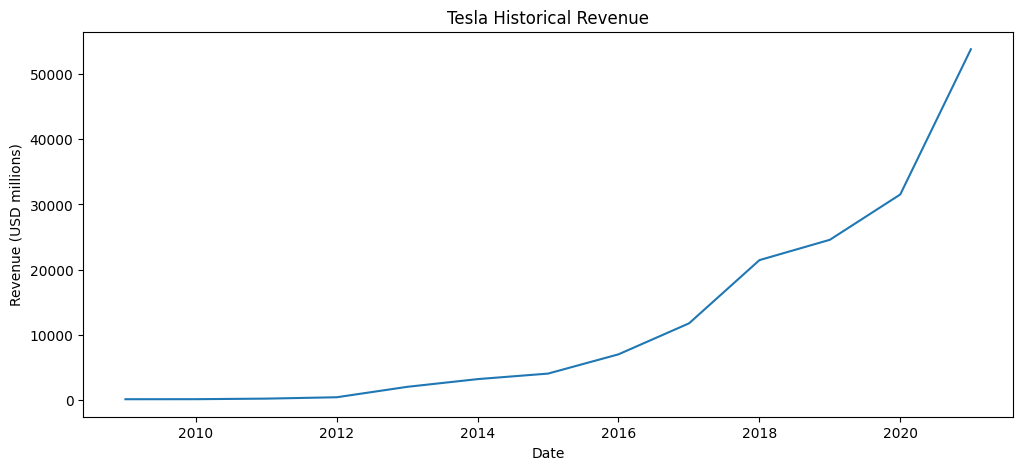

In [137]:
# Plotting Tesla Historical Revenue using Matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(tesla_revenue['Date'],tesla_revenue['Revenue'])
plt.title("Tesla Historical Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (USD millions)")

plt.show()

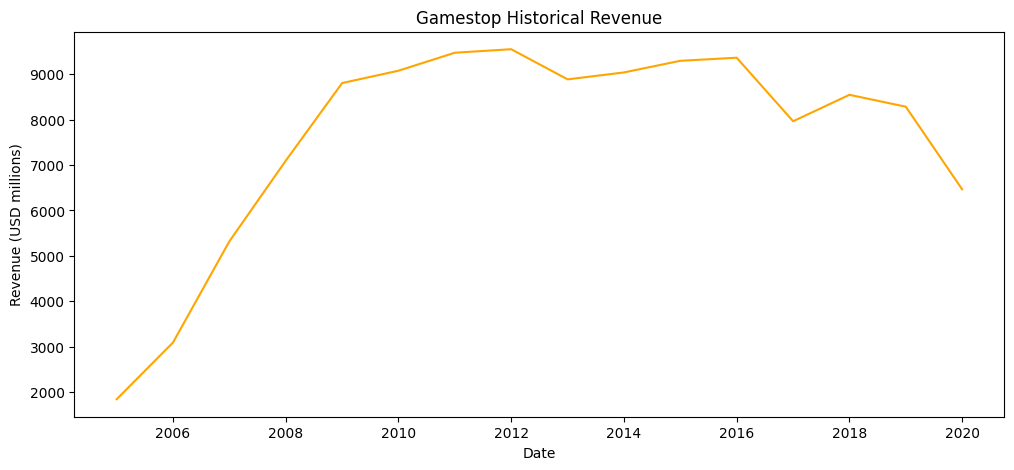

In [138]:
# Plotting Gamestop Historical Revenue using Matplotlib

plt.figure(figsize=(12,5))
plt.plot(gamestop_revenue['Date'],gamestop_revenue['Revenue'], color='orange')
plt.title("Gamestop Historical Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (USD millions)")

plt.show()

In [139]:
# Creating merged data frame including both Tesla Revenue and Gamestop Revenue

tesla_revenue["Year"] = tesla_revenue["Date"].dt.year
gamestop_revenue["Year"] = gamestop_revenue["Date"].dt.year

revenue_comparison = pd.merge(tesla_revenue[["Year", "Revenue"]],gamestop_revenue[["Year", "Revenue"]],on="Year",suffixes=(" Tesla", " GameStop"))

revenue_comparison.columns = ["Year","Tesla Revenue","GameStop Revenue"]
revenue_comparison

,Year,Tesla Revenue,GameStop Revenue
0,2009,112,8806
1,2010,117,9078
2,2011,204,9474
3,2012,413,9551
4,2013,2013,8887
5,2014,3198,9040
6,2015,4046,9296
7,2016,7000,9364
8,2017,11759,7965
9,2018,21461,8547


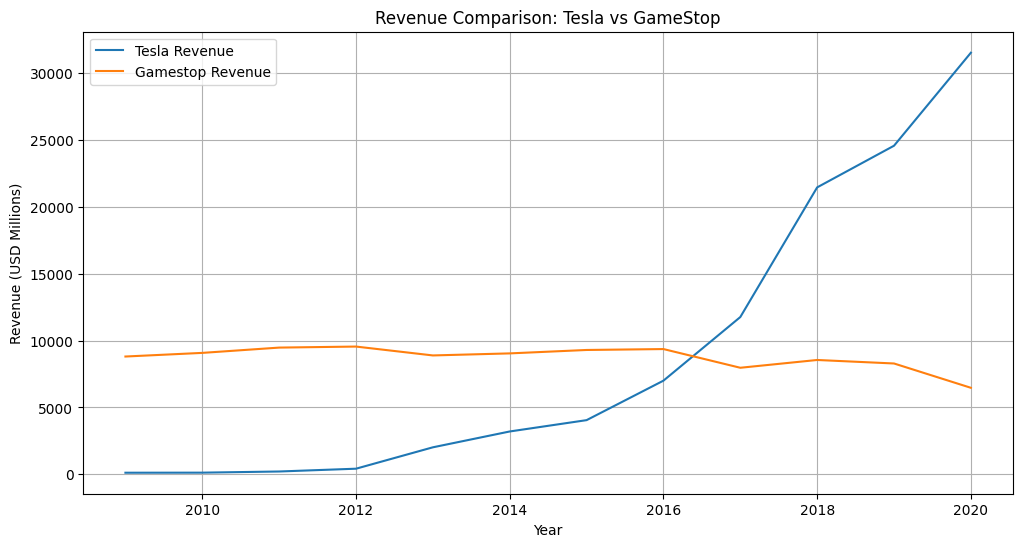

In [140]:
# Plotting Line Chart for Revenue Comparison for Tesla and Gamestop

plt.figure(figsize=(12,6))
plt.plot(revenue_comparison['Year'],revenue_comparison['Tesla Revenue'],label='Tesla Revenue')
plt.plot(revenue_comparison['Year'],revenue_comparison['GameStop Revenue'],label='Gamestop Revenue')
plt.title("Revenue Comparison: Tesla vs GameStop")
plt.xlabel("Year")
plt.ylabel("Revenue (USD Millions)")
plt.legend()
plt.grid(True)

plt.show()

## 5-2-Comparison Between Tesla and Gamestop Revenue Growth

In [141]:
# Tesla Revenue Growth
tesla_revenue['Revenue_Growth_%']=tesla_revenue['Revenue'].pct_change()*100

tesla_revenue.head()

,Date,Revenue,Year,Revenue_Growth_%
12,2009-01-01,112,2009,NaN
11,2010-01-01,117,2010,4.464286
10,2011-01-01,204,2011,74.358974
9,2012-01-01,413,2012,102.450980
8,2013-01-01,2013,2013,387.409201


In [142]:
# Gamestop Revenue Growth
gamestop_revenue['Revenue_Growth_%']=gamestop_revenue['Revenue'].pct_change()*100
gamestop_revenue.head()

,Date,Revenue,Year,Revenue_Growth_%
15,2005-01-01,1843,2005,NaN
14,2006-01-01,3092,2006,67.769940
13,2007-01-01,5319,2007,72.024580
12,2008-01-01,7094,2008,33.370934
11,2009-01-01,8806,2009,24.133070


In [143]:
# Creating data frame including common years, Tesla Growth Percentage and Gamestop Growth Percentage

revenue_growth_comparison = pd.merge(tesla_revenue[["Year", "Revenue_Growth_%"]],gamestop_revenue[["Year", "Revenue_Growth_%"]],on="Year",suffixes=(" Tesla", " GameStop"))
revenue_growth_comparison.columns = ["Year","Tesla Growth %","GameStop Growth %"]

revenue_growth_comparison

,Year,Tesla Growth %,GameStop Growth %
0,2009,NaN,24.133070
1,2010,4.464286,3.088803
2,2011,74.358974,4.362194
3,2012,102.450980,0.812751
4,2013,387.409201,-6.952152
5,2014,58.867362,1.721616
6,2015,26.516573,2.831858
7,2016,73.010381,0.731497
8,2017,67.985714,-14.940196
9,2018,82.507016,7.306968


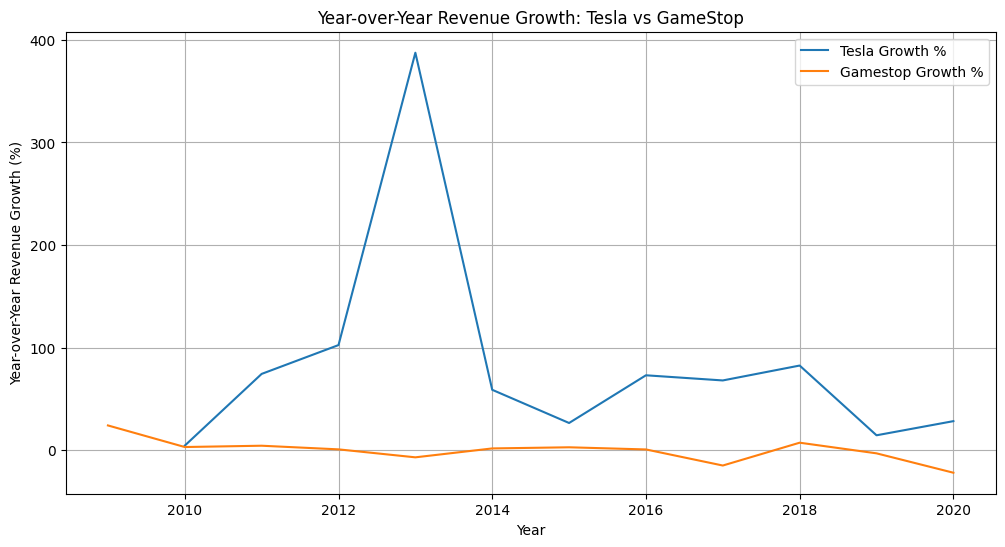

In [144]:
# Plotting Line Chart for Revenue Growth % for Tesla and Gamestop

plt.figure(figsize=(12,6))
plt.plot(revenue_growth_comparison['Year'],revenue_growth_comparison['Tesla Growth %'],label='Tesla Growth %')
plt.plot(revenue_growth_comparison['Year'],revenue_growth_comparison['GameStop Growth %'],label='Gamestop Growth %')
plt.title("Year-over-Year Revenue Growth: Tesla vs GameStop")
plt.xlabel("Year")
plt.ylabel("Year-over-Year Revenue Growth (%)")
plt.legend()
plt.grid(True)

plt.show()

## 5-3-Comparison Between Tesla and Gamestop Stock Performance

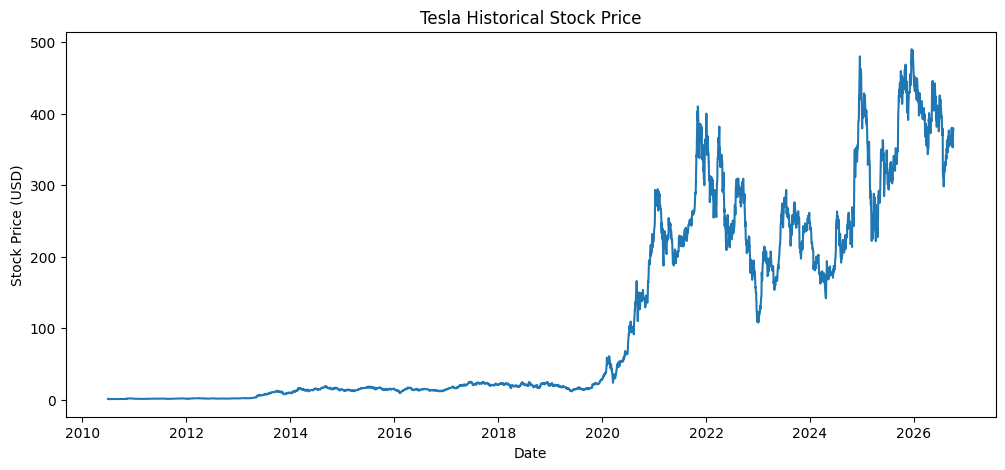

In [145]:
# Plotting Tesla Historical Stock Price using Matplotlib

plt.figure(figsize=(12,5))
plt.plot(tesla_data['Date'],tesla_data['Close'])
plt.title("Tesla Historical Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")

plt.show()



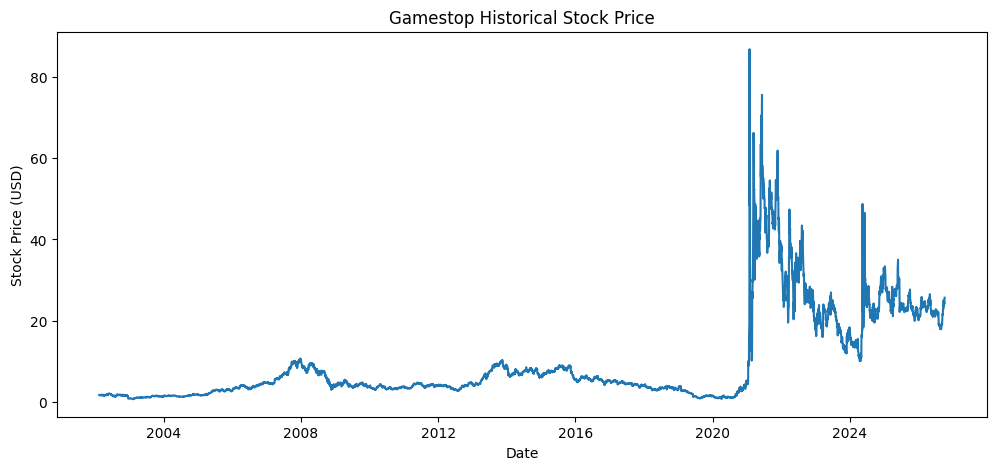

In [146]:
# Plotting Gamestop Historical Stock Price using Matplotlib

plt.figure(figsize=(12,5))
plt.plot(gamestop_data['Date'],gamestop_data['Close'])
plt.title("Gamestop Historical Stock Price")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")

plt.show()


In [147]:
# Analyzing minimum stock price of Tesla:
tesla_data.loc[tesla_data["Close"].idxmin()]


,5
Date,2010-07-07 00:00:00-04:00
Open,1.093333
High,1.108667
Low,0.998667
Close,1.053333
Volume,103825500
Dividends,0.0
Stock Splits,0.0


In [148]:
# Analyzing maximum stock price of Tesla:
tesla_data.loc[tesla_data["Close"].idxmax()]

,3891
Date,2025-12-16 00:00:00-05:00
Open,472.209991
High,491.5
Low,465.829987
Close,489.880005
Volume,107608100
Dividends,0.0
Stock Splits,0.0


In [149]:
# Analyzing minimum stock price of Gamestop:
gamestop_data.loc[gamestop_data["Close"].idxmin()]


,250
Date,2003-02-11 00:00:00-05:00
Open,0.658151
High,0.672459
Low,0.631219
Close,0.638794
Volume,5256000
Dividends,0.0
Stock Splits,0.0


In [150]:
# Analyzing maximum stock price of Gamestop:
gamestop_data.loc[gamestop_data["Close"].idxmax()]

,4771
Date,2021-01-27 00:00:00-05:00
Open,88.707497
High,95.0
Low,62.25
Close,86.877502
Volume,373586800
Dividends,0.0
Stock Splits,0.0


In [151]:
# Creating merged data frame including close price for both of Tesla and Gamestop

stock_comparison = pd.merge(tesla_data[["Date", "Close"]], gamestop_data[["Date", "Close"]], on="Date", suffixes=(" Tesla", " GameStop"))

stock_comparison.columns = ["Date","Tesla Close","GameStop Close"]
stock_comparison.head()

,Date,Tesla Close,GameStop Close
0,2010-06-29 00:00:00-04:00,1.592667,3.083715
1,2010-06-30 00:00:00-04:00,1.588667,3.162828
2,2010-07-01 00:00:00-04:00,1.464000,3.209959
3,2010-07-02 00:00:00-04:00,1.280000,3.075298
4,2010-07-06 00:00:00-04:00,1.074000,3.097180


In [152]:
# Normalizing stock prices to a common base of 100 to compare the relative performance of Tesla and GameStop, regardless of their different starting stock prices.
stock_comparison["Tesla Normalized"] = (stock_comparison["Tesla Close"] /stock_comparison["Tesla Close"].iloc[0]) * 100

stock_comparison["GameStop Normalized"] = (stock_comparison["GameStop Close"] /stock_comparison["GameStop Close"].iloc[0]) * 100
stock_comparison.head()

,Date,Tesla Close,GameStop Close,Tesla Normalized,GameStop Normalized
0,2010-06-29 00:00:00-04:00,1.592667,3.083715,100.000000,100.000000
1,2010-06-30 00:00:00-04:00,1.588667,3.162828,99.748852,102.565502
2,2010-07-01 00:00:00-04:00,1.464000,3.209959,91.921287,104.093880
3,2010-07-02 00:00:00-04:00,1.280000,3.075298,80.368337,99.727046
4,2010-07-06 00:00:00-04:00,1.074000,3.097180,67.434059,100.436646


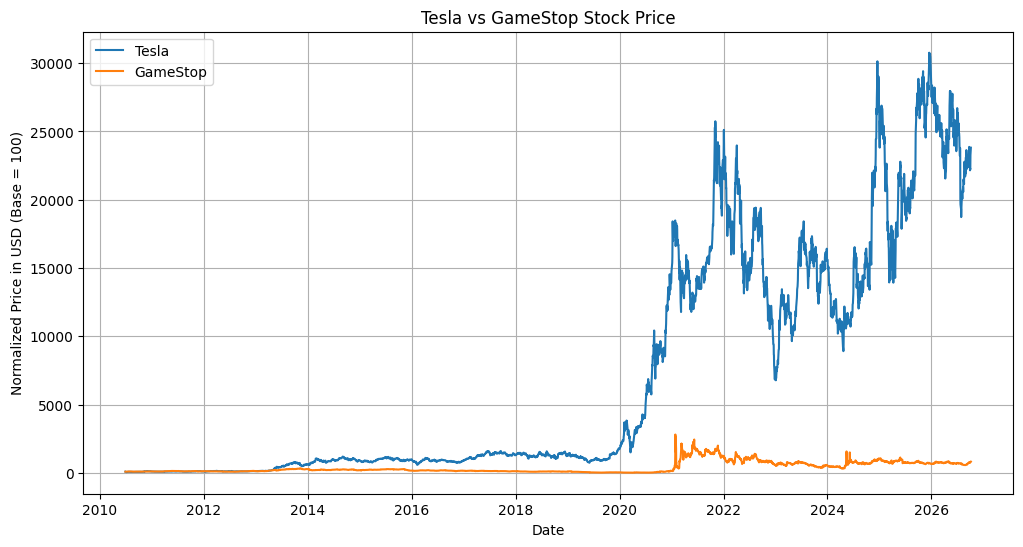

In [153]:
# Stock Price Comparison Graph

plt.figure(figsize=(12, 6))

plt.plot(stock_comparison["Date"], stock_comparison["Tesla Normalized"], label="Tesla")
plt.plot(stock_comparison["Date"], stock_comparison["GameStop Normalized"], label="GameStop")

plt.title("Tesla vs GameStop Stock Price")
plt.xlabel("Date")
plt.ylabel("Normalized Price in USD (Base = 100)")
plt.legend()
plt.grid(True)

plt.show()

#6-Creating Interactive Visualizations Using Plotly

In [154]:
# Creating Revenue Comparison Interactive Graph
import plotly.express as px

fig = px.line(revenue_comparison, x="Year", y=["Tesla Revenue", "GameStop Revenue"],title="Tesla vs GameStop Revenue",color_discrete_map={"Tesla Revenue": "blue","GameStop Revenue": "orange"})

fig.update_layout(xaxis_title="Year", yaxis_title="Revenue (USD millions)")

fig.show()

In [155]:
# Creating Revenue Growth Comparison Interactive Graph


fig = px.line(revenue_growth_comparison,x="Year",y=["Tesla Growth %", "GameStop Growth %"],title="Year-over-Year Revenue Growth: Tesla vs GameStop",
color_discrete_map={"Tesla Growth %": "blue","GameStop Growth %": "orange"})

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Year-over-Year Revenue Growth (%)"
)

fig.show()

In [156]:
# Creating Stock Price Comparison Interactive Graph
fig = px.line(stock_comparison,x="Date",y=["Tesla Normalized", "GameStop Normalized"],
    title="Normalized Tesla vs GameStop Stock Performance",
    color_discrete_map={"Tesla Normalized": "blue","GameStop Normalized": "orange"})

fig.update_layout(xaxis_title="Date",yaxis_title="Normalized Price (Base = 100)")

fig.show()

#7-Key Insights

- Tesla's revenue grew dramatically from $112 million in 2009 to $31.54 billion in 2020, while GameStop's revenue peaked at approximately $9.55 billion in 2012 before declining.

- Tesla maintained positive year-over-year revenue growth throughout 2010–2020, with its highest growth rate reaching approximately 387.41% in 2013.

- GameStop's revenue growth was more mixed, with negative year-over-year growth in several years, including a 21.96% decline in 2020.

- The two companies showed very different revenue trajectories: Tesla experienced rapid long-term expansion, while GameStop's revenue remained relatively stable before entering a declining trend.

- Stock price movements differed substantially from revenue trends, highlighting that stock performance cannot be explained by revenue growth alone.

- Normalizing stock prices to a common base of 100 provides a clearer comparison of Tesla's and GameStop's relative stock performance despite their different starting prices.

#8-Conclusion

This analysis highlights the significantly different business and stock performance patterns of Tesla and GameStop. Tesla demonstrated strong long-term revenue expansion, supported by consistently positive year-over-year growth and substantial increases in revenue over the analyzed period. In contrast, GameStop experienced relatively stable revenue in the earlier years followed by a declining trend and more variable year-over-year growth.

The stock analysis also showed that stock price performance does not necessarily move in line with revenue performance. Comparing normalized stock prices provided a clearer view of the relative performance of both companies from the same starting point, regardless of their different initial stock prices.

Overall, combining revenue trends, revenue growth, historical stock prices, and normalized stock performance provides a more comprehensive view of how the two companies evolved over time. The analysis demonstrates the value of using multiple financial indicators rather than relying on a single metric when evaluating company performance.

#9-Creating Online Interactive Dashboard Using Streamlit

In [157]:
# Creating CSV files for the latest data
revenue_comparison.to_csv("revenue_comparison.csv", index=False)
revenue_growth_comparison.to_csv("revenue_growth_comparison.csv", index=False)
stock_comparison.to_csv("stock_comparison.csv", index=False)


In [158]:
%%writefile requirements.txt

streamlit
pandas
plotly

Writing requirements.txt


In [159]:
%%writefile app.py

Writing app.py


In [160]:
# App.py file is uploaded on githun and deployed on streaamlit cloud.
# Interactive Dashboard link:https://project-stock-performance-revenue-analysis-tesla-vs-gamestop-d.streamlit.app/